# Lab 2.1: Point operations


In [ ]:
!wget -nc -qq -O giraffe-portrait.jpg "https://www.dropbox.com/scl/fi/mzohe12b6absepe92ovq8/giraffe-portrait.jpg?rlkey=go4vawy9c7rwm1zk3lfc78vl1&dl=1"

In [ ]:
# All imports
import imageio
import matplotlib.pyplot as plt
import numpy as np
from skimage.color import rgb2hsv
from skimage.filters import threshold_otsu
from skimage.morphology import disk, closing

Image credit: [Petr Kratochvil](https://www.publicdomainpictures.net/en/view-image.php?image=38397&picture=giraffe-portrait)

## Exercises

1. Show the 'giraffe-portrait.jpg' image.

Show each channel separate (red, green and blue).

Show its red/green/blue histogram.  Interpret the histogram.

*Note: put your text response in a text/Markdown cell, not in code comments.*

/tmp/ipykernel_836/874984266.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('giraffe-portrait.jpg')


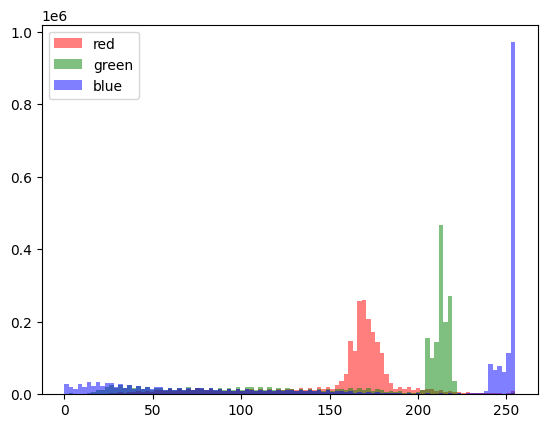

In [ ]:
def show_channels(image, channels):
  colors = ['red', 'green', 'blue', 'orange', 'pink', 'yellow']
  for i,channel in enumerate(channels):
    plt.hist(image[:,:,i].flatten(),bins=100,color=colors[i],alpha=0.5)
  plt.legend(channels)
  plt.show()

def fn_1():
  image = imageio.imread('giraffe-portrait.jpg')
  channels = ['red','green','blue']
  show_channels(image, channels)

fn_1()


2. Invert the image (compute one minus the image) and show it.  What does this do to the colors in the image?

/tmp/ipykernel_836/2718154842.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('giraffe-portrait.jpg')


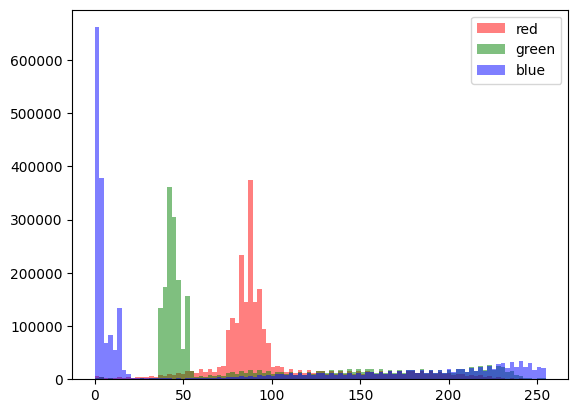

In [ ]:
def show_inverted_channels(image, channels):
  inverted = 1-image
  show_channels(inverted, channels)

def fn_2():
  image = imageio.imread('giraffe-portrait.jpg')
  channels = ['red','green','blue']
  show_inverted_channels(image, channels)

fn_2()


3. Convert the image to the [Hue Saturation Value](https://en.wikipedia.org/wiki/HSL_and_HSV) colorspace (see [`skimage.color.rgb2hsv`](https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_rgb_to_hsv.html)).

Show each channel of the HSV image (hue, saturation, and value).

Show the histograms for the HSV image.



/tmp/ipykernel_836/3639853977.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('giraffe-portrait.jpg')


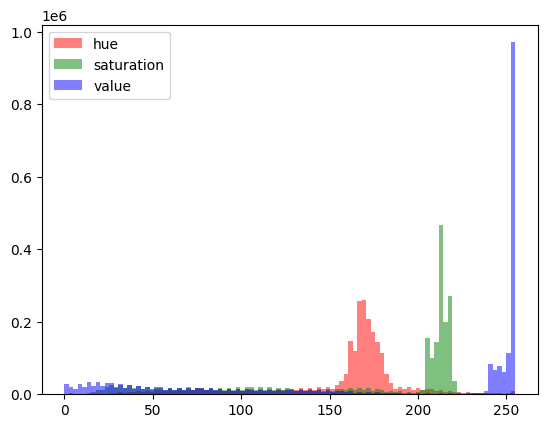

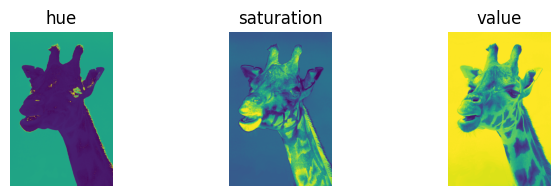

In [ ]:
def fn_3():
  image = imageio.imread('giraffe-portrait.jpg')
  hsv_image = rgb2hsv(image)
  hue_img = hsv_image[:, :, 0]
  satuation_img = hsv_image[:, :, 1]
  value_img = hsv_image[:, :, 2]

  channels = ['hue', 'saturation', 'value']
  show_channels(image, channels)

  # =============================================================

  fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(8, 2))

  ax0.imshow(hue_img)
  ax0.set_title("hue")
  ax0.axis('off')

  ax1.imshow(satuation_img)
  ax1.set_title("saturation")
  ax1.axis('off')

  ax2.imshow(value_img)
  ax2.set_title("value")
  ax2.axis('off')


fn_3()

5. Identify which channel provides the best background/foreground segmentation by applying Otsu's method to each channel and showing the results.  Interpret (qualitatively) which channel seems to work best.

*Note:* For this image, you will want to label the pixels *less than* the threshold as the foreground, i.e. `mask = channel < thresh`.

/tmp/ipykernel_836/3459621146.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('giraffe-portrait.jpg')


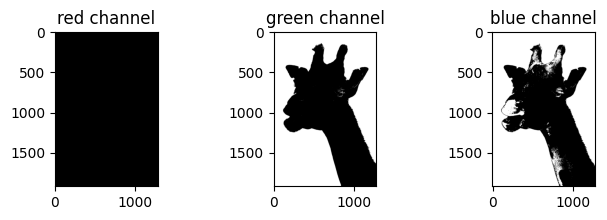

In [ ]:
def generate_mask(background_image, image):
  difference = abs(background_image - image)
  thresh = threshold_otsu(difference)
  binary_mask = difference > thresh
  return binary_mask

def fn_5():
  image = imageio.imread('giraffe-portrait.jpg')
  red_channel = image[:, :, 0]
  green_channel = image[:, :, 1]
  blue_channel = image[:, :, 2]

  fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(8, 2))

  red_mask = generate_mask(image[:, :, 0], red_channel)
  ax0.imshow(red_mask, cmap='gray')
  ax0.set_title('red channel')

  green_mask = generate_mask(image[:, :, 0], green_channel)
  ax1.imshow(green_mask, cmap='gray')
  ax1.set_title('green channel')

  blue_mask = generate_mask(image[:, :, 0], blue_channel)
  ax2.imshow(blue_mask, cmap='gray')
  ax2.set_title('blue channel')

# The green channel seems to seperate the background and the subject for this
# particular image. Not a lot of white is in the giraffe, and not a lot of
# black is in the background
fn_5()

6. Using the channel you selected, clean up your segmentation applying the morphological "closing" operation (`skimage.morphology.closing`).  Set the `footprint` argument to a disk of radius 20 (`skimage.morphology.disk`).

/tmp/ipykernel_836/1038974712.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('giraffe-portrait.jpg')


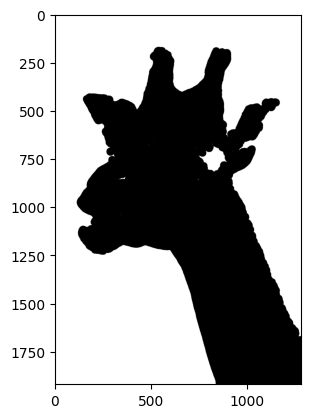

In [ ]:
def generate_green_closing(image):
  green_channel = image[:, :, 1]
  green_mask = generate_mask(image[:, :, 0], green_channel)

  footprint = disk(20)
  return closing(green_mask, footprint=footprint)

def fn_6():
  # I choose the green channel
  image = imageio.imread('giraffe-portrait.jpg')
  green_morph = generate_green_closing(image)

  plt.imshow(green_morph, cmap='gray')
  plt.show()

fn_6()

7. Show the final segmentation result by setting the background pixels of the original image to white.

/tmp/ipykernel_836/2890263452.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('giraffe-portrait.jpg')


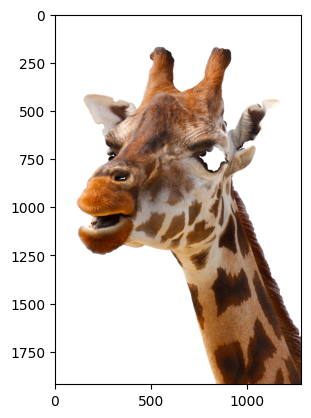

In [ ]:
def fn_7():
  image = imageio.imread('giraffe-portrait.jpg')
  green_morph = generate_green_closing(image)

  # binary mask that is true when the green_morph is white
  mask = green_morph != 0

  # If the mask is white in green_morph, then set that value to 255 in the original image
  image[mask] = 255

  plt.imshow(image)
  plt.show()

fn_7()